In [11]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import matplotlib.pyplot as plt
 
np.random.seed(0)
torch.manual_seed(0)

# GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# torch.cuda.set_device(0)
print(f"Using device: {device}")


## Single-agent Dynamics

dt = 0.5   # Time step
r = 0.2   # Look-ahead Reference distance

A_i = torch.tensor([[1, 0], 
                    [0, 1]], dtype=torch.float32, device=device)   # Dynamics matrix for each agent
B_i = torch.tensor([[dt,  0], 
                    [ 0, dt]], dtype=torch.float32, device=device)   # Control matrix for each agent

## Multi-agent System

N = 5   # Number of agents
n = 2   # Number of states x(k)
m = np.array([2, 2, 2, 2, 2])   # Number of actions u(k)
m_sum = np.sum(m)   # Total number of actions

L_complex, V_complex = torch.linalg.eig(A_i)
print("Eigenvalues of A_i:", L_complex)
A = torch.kron(torch.eye(N), A_i)   # Dynamics matrix for the system
B = torch.kron(torch.eye(N), B_i)   # Control matrix for the system
 
Laplacian = np.array([[ 1,  0, -1,  0,  0], 
                      [ 0,  1, -1,  0,  0], 
                      [-1, -1,  3, -1,  0],
                      [ 0,  0, -1,  2, -1],
                      [ 0,  0,  0, -1,  1]])   # Laplacian matrix

Adjacency = np.array([[0, 0, 1, 0, 0], 
                      [0, 0, 1, 0, 0], 
                      [1, 1, 0, 1, 0],
                      [0, 0, 1, 0, 1],
                      [0, 0, 0, 1, 0]])   # Adjacency matrix

S = torch.tensor(Laplacian, dtype=torch.float32, device=device)   # Weighted adjacency matrix

# 1. 定义队形参数
spacing = 0.5  # 设定小车之间的间距 (米)

# 2. 构建偏置向量 (Formation Offsets)
# 目标: x 对齐 (x_offset=0), y 等间距 (y_offset 递增), 中心对称
formation_offsets = torch.zeros((N * n, 1), dtype=torch.float32, device=device)

for i in range(N):
    # 计算 y 方向的偏置 (让它们沿 y 轴排开)
    # i - (N-1)/2 会生成: -2, -1, 0, 1, 2 (当N=5)
    y_bias = (i - (N - 1) / 2) * spacing
    x_bias = 0.0  # x方向偏置为0，保证 x 坐标一致
    
    # 填入向量: 偶数索引是 x, 奇数索引是 y
    formation_offsets[i * n, 0] = x_bias      # x
    formation_offsets[i * n + 1, 0] = y_bias  # y

print("Formation Offsets (X, Y):\n", formation_offsets.view(N, n))

Using device: cpu
Eigenvalues of A_i: tensor([1.+0.j, 1.+0.j])
Formation Offsets (X, Y):
 tensor([[ 0.0000, -1.0000],
        [ 0.0000, -0.5000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.5000],
        [ 0.0000,  1.0000]])


In [12]:
## GNN Controller
from torch.utils.data import TensorDataset, DataLoader

class GNN0(torch.nn.Module):
    def __init__(self, N, n, m, S):
        super(GNN0, self).__init__()
        self.S = S.to(device)    # Support matrix
        self.L = 2    # Number of layers
        self.n0 = n
        self.n1 = 16
        self.n2 = n
        self.m = m
        self.m_sum = np.sum(m)

        self.H1 = torch.nn.Parameter(torch.randn(self.n1, self.n0, dtype=torch.float32)*0.1)
        self.H2 = torch.nn.Parameter(torch.randn(self.n2, self.n1, dtype=torch.float32)*0.1)
        K = torch.zeros((self.m_sum, N*self.n2), dtype=torch.float32)
        mask_K = torch.zeros_like(K)
        start_idx = 0
        for i in range(N):
            block_size = m[i]
            end_idx = start_idx + block_size
            K[start_idx: end_idx, i*self.n2: (i+1)*self.n2] = torch.randn(block_size, self.n2)*0.1
            mask_K[start_idx: end_idx, i*self.n2: (i+1)*self.n2] = 1
            start_idx = end_idx
        self.K = torch.nn.Parameter(K)
        self.mask_K = mask_K
        
    def forward(self, X):
        X0 = X
        H1 = torch.kron(S, self.H1) @ X0 
        X1 = torch.relu(H1)
        H2 = torch.kron(S, self.H2) @ X1 
        X2 = torch.relu(H2)
        K = self.K * self.mask_K
        return K @ X2
    
gnn = GNN0(N, n, m, S).to(device)   # GNN model

# Cost function
T = 150   # Time horizon
Q = 1 * torch.eye(N*n, dtype=torch.float32, device=device)   # State cost matrix
R = 1 * torch.eye(m_sum, dtype=torch.float32, device=device)   # Action cost matrix

def cost(X_batch, U_batch):
    J = 0
    for k in range(T):       
        e_batch = torch.zeros((batch_size, 0), dtype=torch.float32, device=device)   # Error vector 32*edgesn
        for i in range(N):   # Loop over agents
            e_i_batch = torch.zeros((batch_size, n), dtype=torch.float32, device=device)   # Error vector for agent i
            for j in range(N):   # Loop over neighbors
                if Adjacency[i, j] == 1:
                    offset_diff = (formation_offsets[i*n: (i+1)*n] - formation_offsets[j*n: (j+1)*n]).T
                    e_i_batch += X_batch[:, i*n: (i+1)*n] - X_batch[:, j*n: (j+1)*n] - offset_diff
            e_i_batch /= Laplacian[i, i]
            e_batch = torch.cat((e_batch, e_i_batch), 1)
        J += torch.sum(e_batch @ Q @ e_batch.T) + torch.sum(U_batch @ R @ U_batch.T)
        
        # Prepare input for GNN: Subtract formation offsets
        # X_batch is (32, 10), offsets is (10, 1) -> (1, 10)
        X_input = (X_batch - formation_offsets.T).T  # Transpose to (10, 32)
        
        U = gnn(X_input)      # 10*32
        
        X = X_batch.T
        X = A @ X + B @ U # + 0.1 * torch.randn_like(X)
        X_batch = X.T
        U_batch = U.T
    return J


# Data generation
training_data = 10000   # Number of training data

X_data_np = np.zeros((training_data, N*n), dtype=np.float32)
for i in range(N): 
    X_data_np[:, i*n: i*n + 1] = 1.4 + 1.4 * np.random.randn(training_data, 1)  # x: 0~2.8m
    X_data_np[:, i*n + 1: i*n + 2] = 1 + 2.8 * np.random.randn(training_data, 1)  # y: -1.8~3.8m    
U_data_np = np.random.randn(training_data, m_sum).astype(np.float32)

X_data = torch.tensor(X_data_np, dtype=torch.float32, device=device, requires_grad=True)
U_data = torch.tensor(U_data_np, dtype=torch.float32, device=device, requires_grad=True)

# Create dataset
dataset = TensorDataset(X_data, U_data)

Start Retraining: Range X[0.0, 2.8], Y[-1.8, 3.8]
Epoch 0, Loss: 826.3983 [New Best Saved!]
Epoch 50, Loss: 411.1328
Epoch 100, Loss: 410.7577
Epoch 150, Loss: 410.4896
Epoch 200, Loss: 410.1337 [New Best Saved!]
Epoch 250, Loss: 409.9679
Epoch 300, Loss: 409.9305
Epoch 350, Loss: 409.9503
Epoch 400, Loss: 409.7743
Epoch 450, Loss: 409.4624 [New Best Saved!]
Epoch 500, Loss: 409.6855
Epoch 550, Loss: 409.6680
Epoch 600, Loss: 409.5942
Epoch 650, Loss: 409.6365
Epoch 700, Loss: 409.4613
Epoch 750, Loss: 409.6327
Epoch 800, Loss: 409.3655
Epoch 850, Loss: 409.4509
Epoch 900, Loss: 409.4502
Epoch 950, Loss: 409.3864
Retraining Finished. Best Loss was: 409.2328


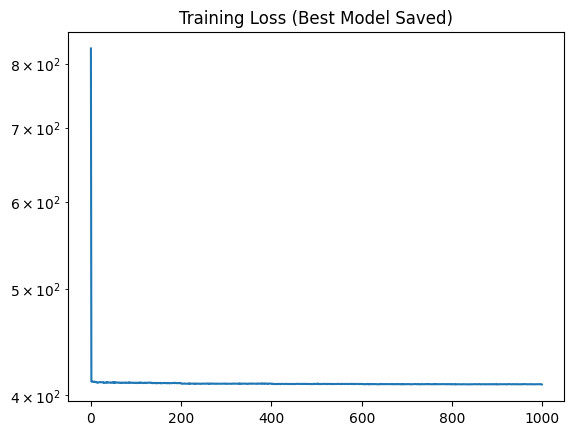

In [142]:
## Training

## 修正后的训练代码 (适配实际场景 + 均匀分布 + 保存最优模型)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import os

# ================= 1. 场景与队形定义 =================
X_MIN, X_MAX = 0.0, 2.8
Y_MIN, Y_MAX = -1.8, 3.8

spacing = 0.5
formation_offsets = torch.zeros((N * n, 1), dtype=torch.float32, device=device)
for i in range(N):
    y_bias = (i - (N - 1) / 2) * spacing
    formation_offsets[i * n, 0] = 0.0
    formation_offsets[i * n + 1, 0] = y_bias

gnn = GNN0(N, n, m, S).to(device)

# ================= 2. 数据生成 (均匀分布) =================
training_data = 30000 
split_idx = int(training_data * 0.8)

X_data_np = np.zeros((training_data, N*n), dtype=np.float32)
Center_data_np = np.zeros((training_data, n), dtype=np.float32)

# 生成随机目标中心
Center_data_np[:, 0] = X_MIN + (X_MAX - X_MIN) * np.random.rand(training_data)
Center_data_np[:, 1] = Y_MIN + (Y_MAX - Y_MIN) * np.random.rand(training_data)

# 生成机器人位置
# 1. 远场随机
X_data_np[:split_idx, 0::2] = X_MIN + (X_MAX - X_MIN) * np.random.rand(split_idx, N)
X_data_np[:split_idx, 1::2] = Y_MIN + (Y_MAX - Y_MIN) * np.random.rand(split_idx, N)

# 2. 近场微调
for i in range(N):
    target_offset_x = formation_offsets[i*n, 0].item()
    target_offset_y = formation_offsets[i*n+1, 0].item()
    base_x = Center_data_np[split_idx:, 0] + target_offset_x
    base_y = Center_data_np[split_idx:, 1] + target_offset_y
    noise_x = 0.2 * (np.random.rand(training_data - split_idx) - 0.5)
    noise_y = 0.2 * (np.random.rand(training_data - split_idx) - 0.5)
    X_data_np[split_idx:, i*n]     = base_x + noise_x
    X_data_np[split_idx:, i*n + 1] = base_y + noise_y

X_data_np[:, 0::2] = np.clip(X_data_np[:, 0::2], X_MIN, X_MAX)
X_data_np[:, 1::2] = np.clip(X_data_np[:, 1::2], Y_MIN, Y_MAX)
U_data_np = np.random.randn(training_data, m_sum).astype(np.float32)

X_data = torch.tensor(X_data_np, dtype=torch.float32, device=device, requires_grad=True)
U_data = torch.tensor(U_data_np, dtype=torch.float32, device=device, requires_grad=True)
Center_data = torch.tensor(Center_data_np, dtype=torch.float32, device=device)

dataset = TensorDataset(X_data, U_data, Center_data)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, drop_last=True)

# ================= 3. 训练循环 (含 Save Best 机制) =================
T = 30
Q = 10.0 * torch.eye(N*n, dtype=torch.float32, device=device)
R = 1.0 * torch.eye(m_sum, dtype=torch.float32, device=device)

optimizer = torch.optim.Adam(gnn.parameters(), lr=0.005)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.5)

print(f"Start Retraining: Range X[{X_MIN}, {X_MAX}], Y[{Y_MIN}, {Y_MAX}]")

epochs = 1000
loss_history = []
best_loss = float('inf')  # 记录历史最低 Loss

gnn.train()
for epoch in range(epochs):
    epoch_loss = 0
    for X_batch, U_batch, Center_batch in dataloader:
        optimizer.zero_grad()
        
        J = 0
        X_curr = X_batch.T # (N*n, Batch)
        
        # 构建 Batch 化的目标中心
        Center_expanded = Center_batch.repeat(1, N) 
        Center_expanded_T = Center_expanded.T
        Targets_Absolute = formation_offsets + Center_expanded_T
        
        for k in range(T):
            # 1. Consensus Error (相对误差)
            e_batch_list = []
            for i in range(N):
                e_i = torch.zeros((n, 64), device=device)
                for j in range(N):
                    if Adjacency[i, j] == 1:
                        diff_pos = X_curr[i*n:(i+1)*n, :] - X_curr[j*n:(j+1)*n, :]
                        diff_off = formation_offsets[i*n:(i+1)*n] - formation_offsets[j*n:(j+1)*n]
                        e_i += (diff_pos - diff_off)
                if Laplacian[i, i] != 0:
                    e_i /= Laplacian[i, i]
                e_batch_list.append(e_i)
            
            e_matrix = torch.cat(e_batch_list, dim=0) 
            loss_state = torch.sum(e_matrix * (Q @ e_matrix)) 
            
            # 2. GNN 前向 (输入维度修正版)
            X_input_gnn = (X_curr - Targets_Absolute) # (10, 64)
            U_next = gnn(X_input_gnn) # (10, 64)
            
            loss_control = torch.sum(U_next * (R @ U_next))
            J += (loss_state + loss_control) / 64
            
            # 3. 动力学更新
            X_curr = A @ X_curr + B @ U_next
            
        J.backward()
        torch.nn.utils.clip_grad_norm_(gnn.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += J.item()
    
    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    # === [新增] 保存最优模型机制 ===
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(gnn, "gnn_model_best.pth") # 保存表现最好的
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {avg_loss:.4f} [New Best Saved!]")
    elif epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.4f}")

# 最后再保存一个终态，以防万一
torch.save(gnn, "gnn_model_final.pth")
print(f"Retraining Finished. Best Loss was: {best_loss:.4f}")

plt.plot(loss_history)
plt.yscale('log')
plt.title("Training Loss (Best Model Saved)")
plt.show()

Time 1/100, Current Cost: 140.39071655273438
States: tensor([[ 0.0445, -1.4270, -0.2630, -0.8288,  0.9018,  1.0518,  0.8953,  2.8267,
          0.7661,  3.5586]], grad_fn=<PermuteBackward0>)
Actions: tensor([[-1.3473,  1.2179, -0.0554,  0.0619,  4.2287,  7.6318, -2.2617,  3.2160,
          0.8815,  1.4854]], grad_fn=<PermuteBackward0>)
2-Norm: [1.48616638 2.8829258 ]
Time 2/100, Current Cost: 35.25121307373047
States: tensor([[ 1.1282, -0.1761,  0.9080,  0.7264,  0.6642,  1.4195,  0.8953,  2.8267,
          0.7661,  3.5586]], grad_fn=<PermuteBackward0>)
Actions: tensor([[ 2.1674,  2.5017,  2.3419,  3.1103, -0.4752,  0.7353,  0.0000,  0.0000,
          0.0000,  0.0000]], grad_fn=<PermuteBackward0>)
2-Norm: [0.63608103 2.72533836]
Time 3/100, Current Cost: 7.386762619018555
States: tensor([[0.5644, 0.3335, 0.6771, 0.9842, 0.8547, 1.7632, 0.8953, 2.8267, 0.7654,
         3.5597]], grad_fn=<PermuteBackward0>)
Actions: tensor([[-1.1275,  1.0192, -0.4617,  0.5157,  0.3809,  0.6875,  0.0000, 

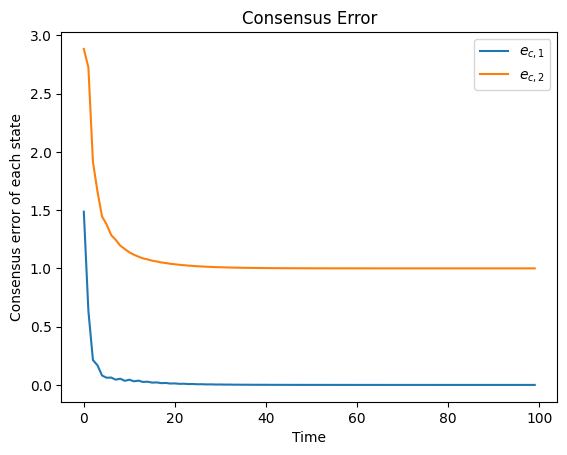

Consensus value for state 1: 0.7660414576530457


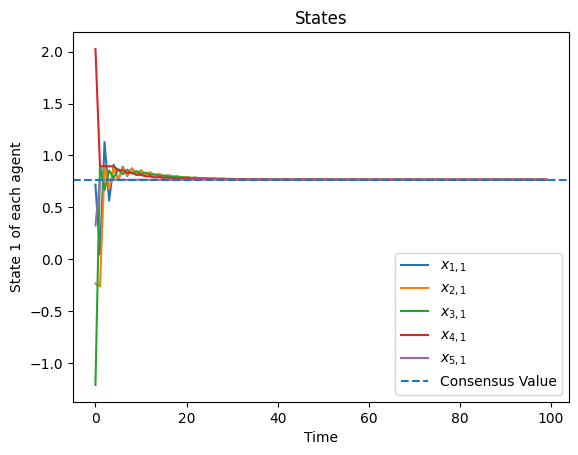

Consensus value for state 2: 2.562554359436035


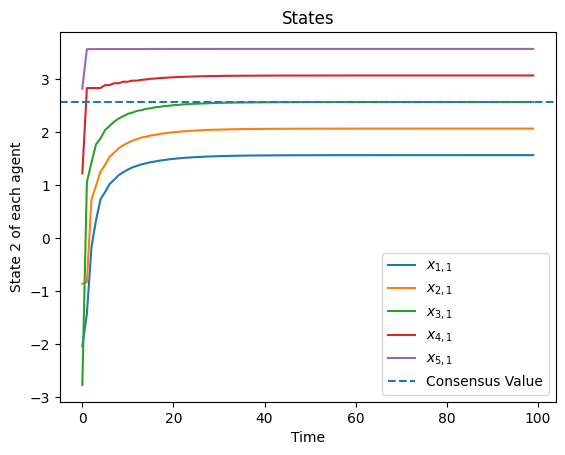

In [4]:
## Test the controller

def cost1(X, U):
    J = 0
    for k in range(T):
        e = torch.empty((N*n, 1), dtype=torch.float32, device=device)   # Error vector
        for i in range(N):
            N_i = np.sum(Adjacency[i, :])   # Number of neighbors of agent i
            e_i = torch.zeros((n, 1), dtype=torch.float32, device=device)   # Error vector for agent i
            for j in range(N):
                if Adjacency[i, j] == 1:   # If agent j is neighbor of agent i
                    offset_diff = formation_offsets[i*n: (i+1)*n] - formation_offsets[j*n: (j+1)*n]
                    e_i += X[i*n: (i+1)*n] - X[j*n: (j+1)*n] - offset_diff
            e_i /= Laplacian[i, i]
            e[i*n: (i+1)*n] = e_i
        J += e.T @ Q.to(device) @ e + U.T @ R.to(device) @ U
        
        # Subtract offsets
        U = gnn(X - formation_offsets)
        X = A @ X + B @ U
    return J

gnn = torch.load("gnn_model_best.pth", weights_only=False).to(device)   # Load the trained model
gnn.eval()

T_test = 100   # Time horizon for testing
x_test = np.zeros((N*n, 1))   # Initial states for testing
for i in range(N):
    x_test[i*n: i*n + 1, :] = 1.4 + 1.4 * np.random.randn(1, 1)  # x: 0~2.8m
    x_test[i*n + 1: i*n + 2, :] = 1 + 2.8 * np.random.randn(1, 1)  # y: -1.8~3.8m

x_test = np.load('good_x_test_config.npy')

u_test = np.zeros((m_sum, 1))   # Initial actions for testing
X_test = torch.tensor(x_test, dtype=torch.float32, device=device)
U_test = torch.tensor(u_test, dtype=torch.float32, device=device)
cost_test = cost1(X_test, U_test).item()   # Initial cost
costs_test = []   # Costs for testing
states = np.zeros((T_test, N*n))
norm_states = np.zeros((T_test, n))   # Variance of the states

for k in range(T_test):
    for state in range(n):
        # var_states[k, state] = torch.var(X_test[state::n]).item()
        x_c = X_test[state::n]  # N*1
        pairwise_diffs = torch.cdist(x_c, x_c, p=2)  # Pairwise Euclidean distances
        upper_tri = torch.triu(pairwise_diffs, diagonal=1)  # Extract upper triangular part
        norm_states[k, state] = upper_tri.sum().item() / (N * (N-1) / 2)  # Compute mean of pairwise distances
    states[k, :] = X_test.detach().cpu().numpy().reshape(N*n)
    
    # Subtract offsets for GNN Input
    U_test = gnn(X_test - formation_offsets)
    
    X_test = A @ X_test + B @ U_test # + 0.1 * torch.randn_like(X_test)
    cost_test = cost1(X_test, U_test).item()
    costs_test.append(cost_test)
    print(f"Time {k+1}/{T_test}, Current Cost: {cost_test}")
    print(f"States: {X_test.T}")
    print(f"Actions: {U_test.T}")
    print(f"2-Norm: {norm_states[k]}")

state_final = states[-1]

# Plot the states difference
plt.figure()
for state in range(n):
    plt.plot(norm_states[:, state], label=rf"$e_{{c, {state + 1}}}$")
plt.xlabel("Time")
plt.ylabel("Consensus error of each state")
plt.title("Consensus Error")
plt.legend()
plt.show()

# Plot the states
for state in range(n):
    plt.figure()
    for i in range(N):
        plt.plot(states[:, i*n + state], label=rf"$x_{{{i + 1}, 1}}$")
        plt.ylabel(f"State {state + 1} of each agent")
    consensus_value = np.mean(state_final[state::n])
    print(f"Consensus value for state {state + 1}: {consensus_value}")
    plt.axhline(y = consensus_value, linestyle='--', label="Consensus Value")
    plt.xlabel("Time")
    plt.title("States")
    plt.legend()
    plt.show()

In [25]:
# Save x_test
if x_test.shape[0] == N*n:
    np.save('good_x_test_config.npy', x_test)
    print(f"Successfully saved x_test (shape {x_test.shape}) to 'good_x_test_config.npy'")
else:
    print(f"Warning: x_test shape is {x_test.shape}, expected ({N*n}, 1). It might have been overwritten by other cells.")

Successfully saved x_test (shape (10, 1)) to 'good_x_test_config.npy'


Loading best model from disk...
>> Success: 'gnn_model_best.pth' loaded!

=== Target Formation: Spacing=1.0m (Sim Y-axis) ===
Agent 1: [sim_x_offset=0.0, sim_y_offset=-2.0]
Agent 2: [sim_x_offset=0.0, sim_y_offset=-1.0]
Agent 3: [sim_x_offset=0.0, sim_y_offset=0.0]
Agent 4: [sim_x_offset=0.0, sim_y_offset=1.0]
Agent 5: [sim_x_offset=0.0, sim_y_offset=2.0]
  Agent 1: (1.35, -1.25) theta=3.14
  Agent 2: (1.15, -0.75) theta=3.10
  Agent 3: (1.90, 1.00) theta=3.14
  Agent 4: (1.00, 1.65) theta=3.18
  Agent 5: (1.40, 3.25) theta=3.12
Initialized Leader at Sim Coords: [x=1.25, y=1.0] (Based on Agent 3)
Starting Simulation...
Step 0: Err=0.470, LeaderX=1.24
Step 100: Err=0.397, LeaderX=0.49
Step 200: Err=0.437, LeaderX=-0.26
Step 300: Err=0.462, LeaderX=-1.01
Step 400: Err=0.479, LeaderX=-1.76

Plotting Results...


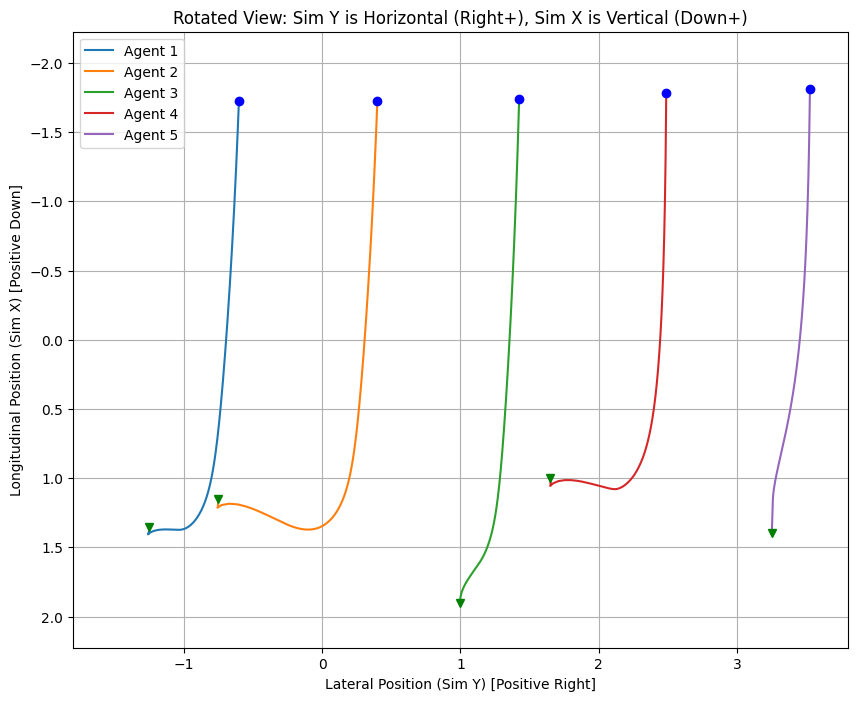

In [ ]:
# [User Request]
# 1. 保持 1.0m 间距 (Spacing=1.0)
# 2. 初始位置 X=1.25 (Start near 1.4), Y Spaced ~1.0
# 3. Y轴变横轴 (Horizontal), 正方向向右
# 4. X轴变纵轴 (Vertical), 正方向向下 (Up is Negative X, Down is Positive X)
# 5. Motion: Move Negative X (Up visually)
# 6. Plot Limits: X 1.4 to -1.4, Y -1.8 to 3.8
# 7. [Update] Virtual Leader Y Base = Agent 3's Y Position (Dynamic)

import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 0. 加载模型
# ==========================================
try:
    print("Loading best model from disk...")
    gnn = torch.load("gnn_model_best.pth", weights_only=False).to(device)
    gnn.eval()
    print(">> Success: 'gnn_model_best.pth' loaded!")
except FileNotFoundError:
    print(">> Warning: 'gnn_model_best.pth' not found! Using current 'gnn' in memory.")

# ==========================================
# 1. 场景与参数设置
# ==========================================
T_test = 450    # 仿真时长
dt = 0.05       # 时间步长
r = 0.2         # 前视距离
spacing = 1.0   # 间距 1.0m
v_cruise = 0.15 # 巡航速度

# 视觉显示范围 (Visualization Limits) [Modified to 1.4 -- -1.4]
VIS_SIM_X_MIN, VIS_SIM_X_MAX = -1.4, 1.4
VIS_SIM_Y_MIN, VIS_SIM_Y_MAX = -1.8, 3.8

# ==========================================
# 2. 定义目标队形 (Sim: Line along Y)
# ==========================================
formation_offsets = torch.zeros((N * n, 1), dtype=torch.float32, device=device)

print(f"\n=== Target Formation: Spacing={spacing}m (Sim Y-axis) ===")
for i in range(N):
    # Agents arranged along Y in simulation frame
    y_bias = (i - (N - 1) / 2) * spacing
    
    formation_offsets[i * n, 0] = 0.0      # X offset (Longitudinal)
    formation_offsets[i * n + 1, 0] = y_bias # Y offset (Lateral)
    print(f"Agent {i+1}: [sim_x_offset=0.0, sim_y_offset={y_bias:.1f}]")

# ==========================================
# 3. 初始化机器人状态 (Manual)
# ==========================================
# Goal: Place agents near Start X=1.25, distributed along Y (Spacing ~1.0)
x_test = np.zeros((N*(n+1), 1))

# Manual positions [sim_x, sim_y, theta]
# Orientation: Facing Negative X (approx 3.14 rad) -> Moving "Up" visually
# X positions shifted to be near 1.25
manual_positions = [
    [1.35, -1.25, 3.14], # Agent 1 (Leftmost)
    [1.15, -0.75, 3.10], # Agent 2
    [1.90, 1.00, 3.14],  # Agent 3 (Center)
    [1.00, 1.65, 3.18],  # Agent 4
    [1.40, 3.25, 3.12],  # Agent 5 (Rightmost)
]

if len(manual_positions) != N:
    raise ValueError(f"Expected {N} initial positions, but got {len(manual_positions)}.")

for i in range(N):
    pos = manual_positions[i]
    x_test[i*(n+1), 0]     = pos[0]
    x_test[i*(n+1) + 1, 0] = pos[1]
    x_test[i*(n+1) + 2, 0] = pos[2] # Heading
    print(f"  Agent {i+1}: ({pos[0]:.2f}, {pos[1]:.2f}) theta={pos[2]:.2f}")

X_test = torch.tensor(x_test, dtype=torch.float32, device=device)

# ==========================================
# [New] Update Virtual Leader based on Agent 3
# ==========================================

# 初始虚拟领航者位置
# Start at X=1.25 (Bottom in inverted view), Move to X=-1.4 (Top)
# Y centered at Agent 3's Y position (Dynamic Binding)
virtual_leader_x = 1.25
virtual_leader_y_base = manual_positions[2][1] # Defined by Agent 3 (Index 2)'s Y pos

print(f"Initialized Leader at Sim Coords: [x={virtual_leader_x}, y={virtual_leader_y_base}] (Based on Agent 3)")


history_states = []

# ==========================================
# 4. 仿真循环
# ==========================================
print(f"Starting Simulation...")
for k in range(T_test):
    current_state_np = X_test.detach().cpu().numpy().flatten()
    history_states.append(current_state_np)

    # A. Move Leader (Negative X direction)
    current_vx = -v_cruise
    virtual_leader_x += current_vx * dt
    
    # Check if out of bounds (Optional stop)
    # if virtual_leader_x < -1.4: break

    # Target positions
    current_targets = formation_offsets.clone()
    current_targets[0::2] += virtual_leader_x
    current_targets[1::2] += virtual_leader_y_base

    # B. GNN Input (Look ahead)
    X_GNN = torch.zeros((N*n, 1), dtype=torch.float32, device=device)
    for i in range(N):
        xi = X_test[i*(n+1), :]
        yi = X_test[i*(n+1) + 1, :]
        thetai = X_test[i*(n+1) + 2, :]
        X_GNN[i*n, :] = xi + r * torch.cos(thetai)
        X_GNN[i*n + 1, :] = yi + r * torch.sin(thetai)

    # C. Error & Control
    error_vector = X_GNN - current_targets
    
    gnn_input = error_vector 
    U_gnn = gnn(gnn_input)
    U_gnn_reshaped = U_gnn.view(N, n) # [ux, uy]
    
    # Feedforward (Velocity in X)
    U_total = U_gnn_reshaped.clone()
    U_total[:, 0] += current_vx 
    
    U_total_flat = U_total.view(N*2, 1)
    
    # Inverse Kinematics
    u_actual = torch.zeros((N*2, 1), dtype=torch.float32, device=device)
    for i in range(N):
        vx_des = U_total_flat[i*2, 0]
        vy_des = U_total_flat[i*2 + 1, 0]
        thetai = X_test[i*(n+1) + 2, 0]
        
        v = vx_des * torch.cos(thetai) + vy_des * torch.sin(thetai)
        w = (-1/r) * torch.sin(thetai) * vx_des + (1/r) * torch.cos(thetai) * vy_des
        u_actual[i*2] = v
        u_actual[i*2 + 1] = w

    # D. Update
    X_next = torch.zeros_like(X_test)
    for i in range(N):
        xi = X_test[i*(n+1), :]
        yi = X_test[i*(n+1) + 1, :]
        thetai = X_test[i*(n+1) + 2, :]
        v = u_actual[i*2]
        w = u_actual[i*2 + 1]
        
        X_next[i*(n+1), :] = xi + v * torch.cos(thetai) * dt
        X_next[i*(n+1) + 1, :] = yi + v * torch.sin(thetai) * dt
        X_next[i*(n+1) + 2, :] = thetai + w * dt
        
    X_test = X_next
    
    if k % 100 == 0:
        error_val = torch.mean(torch.norm(error_vector.view(N, n), dim=1)).item()
        print(f"Step {k}: Err={error_val:.3f}, LeaderX={virtual_leader_x:.2f}")

# ==========================================
# 5. 绘图 (Rotated View)
# ==========================================
print("\nPlotting Results...")
history_states = np.array(history_states)

plt.figure(figsize=(10, 8))

for i in range(N):
    # Sim Coordinates
    sim_x = history_states[:, i*(n+1)]
    sim_y = history_states[:, i*(n+1)+1]
    
    # Plotting Mapping:
    # Horizontal Axis <--- Sim Y
    # Vertical Axis   <--- Sim X
    
    plt.plot(sim_y, sim_x, label=f"Agent {i+1}")
    
    # Start (Green Triangle)
    plt.plot(sim_y[0], sim_x[0], 'gv') 
    # End (Blue Dot)
    plt.plot(sim_y[-1], sim_x[-1], 'bo')

# [CRITICAL] Direction Control
# We want "Positive X" (1.4) to be DOWN. "Negative X" (-1.4) to be UP.
# Standard plot: Y increases Up.
# To reverse this (Y increases Down), we invert.
plt.gca().invert_yaxis()

plt.title("Rotated View: Sim Y is Horizontal (Right+), Sim X is Vertical (Down+)")
plt.xlabel("Lateral Position (Sim Y) [Positive Right]")
plt.ylabel("Longitudinal Position (Sim X) [Positive Down]")

plt.legend()
plt.grid(True)
plt.axis('equal')

# Set Limits
# Horizontal (Y): -1.8 to 3.8
plt.xlim(VIS_SIM_Y_MIN, VIS_SIM_Y_MAX) 

# Vertical (X): 1.4 to -1.4
# We want Bottom = 1.4, Top = -1.4.
plt.ylim(VIS_SIM_X_MAX, VIS_SIM_X_MIN) 

plt.show()

In [131]:
# # Save the model
# torch.save(gnn, "gnn_model_N5_cri_multirobot.pth")

In [28]:
import struct
import os

def export_weights_for_cpp_row_major(model, output_dir='./weights_for_cpp'):
    """
    Export PyTorch weights to binary format (Float32, Row-Major / C-Order)
    compatible with the C++ GNNController::loadWeights implementation.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    print(f"Exporting weights to {output_dir} ...")
    
    # 1. Get Tensors
    # H1, H2 are straightforward
    h1 = model.H1.detach().cpu().numpy().astype(np.float32)
    h2 = model.H2.detach().cpu().numpy().astype(np.float32)
    
    # K needs to be multiplied by mask because C++ does direct multiplication without mask
    # Simulation: K_eff = self.K * self.mask_K
    k_eff = (model.K * model.mask_K).detach().cpu().numpy().astype(np.float32)
    
    # 2. Save as Binary in Row-Major (C-Style) order
    # C++ Code Loop: for i in rows: for j in cols: file.read()
    # This corresponds to 'C' order flattening.
    
    h1_path = os.path.join(output_dir, 'H1.bin')
    h2_path = os.path.join(output_dir, 'H2.bin')
    k_path = os.path.join(output_dir, 'K.bin')
    
    h1.tofile(h1_path) # numpy default is C-order (Row-major)
    h2.tofile(h2_path)
    k_eff.tofile(k_path)
    
    print(f"[Success] Saved H1.bin: shape {h1.shape} -> Row-Major")
    print(f"[Success] Saved H2.bin: shape {h2.shape} -> Row-Major")
    print(f"[Success] Saved K.bin:  shape {k_eff.shape} -> Row-Major (Mask applied)")
    print(f"Please copy the folder '{output_dir}' to your C++ robot project.")

# Execute Export
export_weights_for_cpp_row_major(gnn)

Exporting weights to ./weights_for_cpp ...
[Success] Saved H1.bin: shape (16, 2) -> Row-Major
[Success] Saved H2.bin: shape (2, 16) -> Row-Major
[Success] Saved K.bin:  shape (10, 10) -> Row-Major (Mask applied)
Please copy the folder './weights_for_cpp' to your C++ robot project.
